In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import scipy.interpolate as interpolate

In [3]:
def measure_stats(data):
    cv = np.std(data)/np.mean(data)
    proportion_negative = np.sum(data>=0)/data.size
    if(proportion_negative==1):
        mean_negative = 1.0
    else:
        mean_negative = np.mean(data[data>0]) / (-np.mean(data[data<0]) + np.mean(data[data>0]))
    skew = stats.skew(data)
    kurtosis = stats.kurtosis(data,fisher=True)
    weakness_fraction = np.sum(np.abs(data) < np.std(data)) / data.size
    outlier_fraction = np.sum(np.abs(data - np.mean(data)) > 3*np.std(data)) / data.size
    return proportion_negative, mean_negative, skew, kurtosis, cv, weakness_fraction, outlier_fraction

## Interactions in data

In [4]:
dataset1 = pd.read_csv("../data/interaction_data/stein_et_al/interactions.csv")
data1 = dataset1.to_numpy()
rescaled_data1 = -data1 / np.diag(data1)[:, None]
data1 = rescaled_data1[~np.eye(rescaled_data1.shape[0],dtype=bool),]

hist1,edges1 = np.histogram(data1,bins=25,density=True)
mean1,sd1 = np.mean(data1), np.std(data1)
xrange1 = np.linspace(-8,8,100)
gaussian1 = 1/(sd1*np.sqrt(2*np.pi))*np.exp(-0.5*((xrange1-mean1)/sd1)**2)

within_sd_zero1 = np.sum(np.abs(data1) < sd1) / data1.size * 100
outlier_fraction1 = np.sum(np.abs(data1 - mean1) > 3*sd1) / data1.size * 100
print(f"Stein et al. fraction within 1 SD of zero: {within_sd_zero1:.3f}")
print(f"Stein et al. mean: {mean1:.3f}, std: {sd1:.3f}, median: {np.median(data1):.3f}")
print(f"Stein et al. outlier fraction (>2 SD): {outlier_fraction1:.3f}")

Stein et al. fraction within 1 SD of zero: 85.455
Stein et al. mean: -0.518, std: 1.726, median: -0.084
Stein et al. outlier fraction (>2 SD): 1.818


In [5]:
dataset2 = pd.read_csv("../data/interaction_data/kehe_et_al/sciadv.abi7159_data_s1.csv")
growing_carbons = ["Glucose","Glycerol","Mannose","Glutamine"]
dataset2 = dataset2[dataset2["Carbon"].isin(growing_carbons)]
effects2 = dataset2[["1 on 2: Effect","2 on 1: Effect"]].to_numpy()
data2 = effects2[(effects2!=0).all(axis=1) & ~np.isnan(effects2).any(axis=1)].flatten()

hist2, edges2 = np.histogram(data2,bins=25,density=True)
xrange2 = np.linspace(-6,6,100)
mean2, sd2 = np.mean(data2), np.std(data2)
gaussian2 = 1/(sd2*np.sqrt(2*np.pi))*np.exp(-0.5*((xrange2-mean2)/sd2)**2)

within_sd_zero2 = np.sum(np.abs(data2) < sd2) / data2.size * 100
outlier_fraction2 = np.sum(np.abs(data2 - mean2) > 3*sd2) / data2.size * 100
print(f"Kehe et al. fraction within 1 SD of zero: {within_sd_zero2:.3f}")
print(f"Kehe et al. mean: {mean2:.3f}, std: {sd2:.3f}, median: {np.median(data2):.3f}")
print(f"Kehe et al. outlier fraction (>3 SD): {outlier_fraction2:.3f}")

Kehe et al. fraction within 1 SD of zero: 75.017
Kehe et al. mean: -0.765, std: 1.303, median: -0.615
Kehe et al. outlier fraction (>3 SD): 3.080


In [6]:
dataset3 = pd.read_csv("../data/interaction_data/schaffer_et_al/interaction_data.csv")
data3 = dataset3.to_numpy()[:,1:].astype(float)
data3 = data3[~np.eye(data3.shape[0],dtype=bool),]
data3 = data3[np.where((data3>-5) & (data3<5))]

hist3,edges3 = np.histogram(data3,bins=25,density=True)
mean3,sd3 = np.mean(data3), np.std(data3)
xrange3 = np.linspace(-5,5,100)
gaussian3 = 1/(sd3*np.sqrt(2*np.pi))*np.exp(-0.5*((xrange3-mean3)/sd3)**2)

within_sd_zero3 = np.sum(np.abs(data3) < sd3) / data3.size * 100
outlier_fraction3 = np.sum(np.abs(data3 - mean3) > 3*sd3) / data3.size * 100
print(f"Schaffer et al. fraction within 1 SD of zero: {within_sd_zero3:.3f}")
print(f"Schaffer et al. mean: {mean3:.3f}, std: {sd3:.3f}, median: {np.median(data3):.3f}")
print(f"Schaffer et al. outlier fraction (>3 SD): {outlier_fraction3:.3f}")

Schaffer et al. fraction within 1 SD of zero: 73.876
Schaffer et al. mean: -0.576, std: 1.523, median: -0.005
Schaffer et al. outlier fraction (>3 SD): 0.012


In [8]:
inters_chain = pd.read_csv("../data/interaction_data/ishizawa_et_al/chains_upto_four.csv").to_numpy()[:,1:]
mean_inters = np.mean(inters_chain,axis=0)
inter_matrix = np.reshape(np.array(mean_inters),(7,7)).astype(float)
rescaled_inter_matrix = inter_matrix / np.diag(inter_matrix)
data4 = -rescaled_inter_matrix[~np.eye(rescaled_inter_matrix.shape[0],dtype=bool),]

hist4,edges4 = np.histogram(data4,bins=25,density=True)
mean4,sd4 = np.mean(data4), np.std(data4)
xrange4 = np.linspace(-3,3,100)
gaussian4 = 1/(sd4*np.sqrt(2*np.pi))*np.exp(-0.5*((xrange4-mean4)/sd4)**2)

within_sd_zero4 = np.sum(np.abs(data4) < sd4) / data4.size * 100
outlier_fraction4 = np.sum(np.abs(data4 - mean4) > 3*sd4) / data4.size * 100
print(f"Ishizawa et al. fraction within 1 SD of zero: {within_sd_zero4:.3f}")
print(f"Ishizawa et al. mean: {mean4:.3f}, std: {sd4:.3f}, median: {np.median(data4):.3f}")
print(f"Ishizawa et al. outlier fraction (>3 SD): {outlier_fraction4:.3f}")

Ishizawa et al. fraction within 1 SD of zero: 80.952
Ishizawa et al. mean: -0.003, std: 0.599, median: -0.073
Ishizawa et al. outlier fraction (>3 SD): 2.381


In [9]:
inter5 =  np.load("../data/interaction_data/ho_et_al/eo_interactions.npy")
data5 = -inter5[~np.eye(inter5.shape[0],dtype=bool),]

hist5,edges5 = np.histogram(data5,bins=20,density=True)
mean5,sd5 = np.mean(data5), np.std(data5)
xrange5 = np.linspace(-1,1,100)
gaussian5 = 1/(sd5*np.sqrt(2*np.pi))*np.exp(-0.5*((xrange5-mean5)/sd5)**2)

within_sd_zero5 = np.sum(np.abs(data5) < sd5) / data5.size * 100
outlier_fraction5 = np.sum(np.abs(data5 - mean5) > 3*sd5) / data5.size * 100
print(f"Gut microbiome fraction within 1 SD of zero: {within_sd_zero5:.3f}")
print(f"Gut microbiome mean: {mean5:.3f}, std: {sd5:.3f}, median: {np.median(data5):.3f}")
print(f"Gut microbiome outlier fraction (>3 SD): {outlier_fraction5:.3f}")

Gut microbiome fraction within 1 SD of zero: 65.152
Gut microbiome mean: -0.278, std: 0.290, median: -0.152
Gut microbiome outlier fraction (>3 SD): 0.000


In [10]:
full_dataset6 = pd.read_csv("../data/interaction_data/weiss_et_al/yield_interactions_omm12.csv")
data6 = np.log10(full_dataset6[full_dataset6["group"]=="co"]["mean_rbm"].values)
data6 = data6[~np.isinf(data6)]

hist6,edges6 = np.histogram(data6,bins=20,density=True)
mean6,sd6 = np.mean(data6), np.std(data6)
xrange6 = np.linspace(-5,5,100)
gaussian6 = 1/(sd6*np.sqrt(2*np.pi))*np.exp(-0.5*((xrange6-mean6)/sd6)**2)

within_sd_zero6 = np.sum(np.abs(data6) < sd6) / data6.size * 100
outlier_fraction6 = np.sum(np.abs(data6 - mean6) > 3*sd6) / data6.size * 100
print(f"OMM12 fraction within 1 SD of zero: {within_sd_zero6:.3f}")
print(f"OMM12 mean: {mean6:.3f}, std: {sd6:.3f}, median: {np.median(data6):.3f}")
print(f"OMM12 outlier fraction (>3 SD): {outlier_fraction6:.3f}")

OMM12 fraction within 1 SD of zero: 79.389
OMM12 mean: -0.722, std: 1.155, median: -0.259
OMM12 outlier fraction (>3 SD): 2.290


C:\Users\ppraj\AppData\Local\Temp\ipykernel_27492\301541967.py:2: RuntimeWarning: divide by zero encountered in log10
  data6 = np.log10(full_dataset6[full_dataset6["group"]=="co"]["mean_rbm"].values)


In [11]:
inter7 = np.load("../data/interaction_data/clark_et_al/interaction.npy")
rescaled_inter = inter7 / np.diag(inter7)
data7 = -rescaled_inter[~np.eye(rescaled_inter.shape[0],dtype=bool),]

hist7,edges7 = np.histogram(data7,bins=20,density=True)
mean7,sd7 = np.mean(data7), np.std(data7)
xrange7 = np.linspace(-1,1,100)
gaussian7 = 1/(sd7*np.sqrt(2*np.pi))*np.exp(-0.5*((xrange7-mean7)/sd7)**2)

within_sd_zero7 = np.sum(np.abs(data7) < sd7) / data7.size * 100
outlier_fraction7 = np.sum(np.abs(data7 - mean7) > 3*sd7) / data7.size * 100
print(f"Clark et al. fraction within 1 SD of zero: {within_sd_zero7:.3f}")
print(f"Clark et al. mean: {mean7:.3f}, std: {sd7:.3f}, median: {np.median(data7):.3f}")
print(f"Clark et al. outlier fraction (>3 SD): {outlier_fraction7:.3f}")

Clark et al. fraction within 1 SD of zero: 73.333
Clark et al. mean: -0.122, std: 0.159, median: -0.093
Clark et al. outlier fraction (>3 SD): 2.167


In [12]:
data8 = np.load("../data/interaction_data/flor_et_al/filtered_interactions.npy")

hist8,edges8 = np.histogram(data8,bins=20,density=True)
mean8,sd8 = np.mean(data8), np.std(data8)
xrange8 = np.linspace(-25,15,100)
gaussian8 = 1/(sd8*np.sqrt(2*np.pi))*np.exp(-0.5*((xrange8-mean8)/sd8)**2)

within_sd_zero8 = np.sum(np.abs(data8) < sd8) / data8.size * 100
outlier_fraction8 = np.sum(np.abs(data8 - mean8) > 3*sd8) / data8.size * 100
print(f"Flor et al. fraction within 1 SD of zero: {within_sd_zero8:.3f}")
print(f"Flor et al. mean: {mean8:.3f}, std: {sd8:.3f}, median: {np.median(data8):.3f}")
print(f"Flor et al. outlier fraction (>3 SD): {outlier_fraction8:.3f}")

Flor et al. fraction within 1 SD of zero: 77.419
Flor et al. mean: -1.678, std: 6.755, median: -0.983
Flor et al. outlier fraction (>3 SD): 2.151


In [ ]:
data9 = np.load("../data/interaction_data/merz_et_al/filtered_interactions.npy")

hist9,edges9 = np.histogram(data9,bins=180,density=True)
mean9,sd9 = np.mean(data9), np.std(data9)
xrange9 = np.linspace(-0.02,0.02,100)
gaussian9 = 1/(sd9*np.sqrt(2*np.pi))*np.exp(-0.5*((xrange9-mean9)/sd9)**2)

within_sd_zero9 = np.sum(np.abs(data9) < sd9) / data9.size * 100
outlier_fraction9 = np.sum(np.abs(data9 - mean9) > 3*sd9) / data9.size * 100
print(f"Marine microbiome fraction within 1 SD of zero: {within_sd_zero9:.3f}")
print(f"Marine microbiome mean: {mean9:.3f}, std: {sd9:.3f}, median: {np.median(data9):.3f}")
print(f"Marine microbiome outlier fraction (>3 SD): {outlier_fraction9:.3f}")

Marine microbiome fraction within 1 SD of zero: 93.152
Marine microbiome mean: -0.000, std: 0.007, median: 0.000
Marine microbiome outlier fraction (>3 SD): 2.017


In [15]:
weakness_fractions = [within_sd_zero1, within_sd_zero2, within_sd_zero3, within_sd_zero4, within_sd_zero5, within_sd_zero6, within_sd_zero7, within_sd_zero8, within_sd_zero9]
outlier_fractions = [outlier_fraction1, outlier_fraction2, outlier_fraction3, outlier_fraction4, outlier_fraction5, outlier_fraction6, outlier_fraction7, outlier_fraction8, outlier_fraction9]

print(np.mean(weakness_fractions),np.std(weakness_fractions))
print(np.mean(outlier_fractions),np.std(outlier_fractions))

78.19404209405619 7.517180382723574
1.768316260867467 0.997225636376821


In [16]:
combined_data = [data1,data2,data3,data4,data5,data6,data7,data8,data9]
combined_hists = [(hist1,edges1),(hist2,edges2),(hist3,edges3),(hist4,edges4),(hist5,edges5),(hist6,edges6),(hist7,edges7),(hist8,edges8),(hist9,edges9)]
combined_gaussians = [(xrange1,gaussian1),(xrange2,gaussian2),(xrange3,gaussian3),(xrange4,gaussian4),(xrange5,gaussian5),(xrange6,gaussian6),(xrange7,gaussian7),(xrange8,gaussian8),(xrange9,gaussian9)]
normality_test = [stats.normaltest(cur_data) for cur_data in combined_data]
data_measures = np.array([measure_stats(-cur_data) for cur_data in combined_data])

In [17]:
normality_test

[NormaltestResult(statistic=98.52235816262126, pvalue=4.0377716360259397e-22),
 NormaltestResult(statistic=533.3464564070299, pvalue=1.532104964708773e-116),
 NormaltestResult(statistic=2912.131613156475, pvalue=0.0),
 NormaltestResult(statistic=24.383417560809825, pvalue=5.072337605708211e-06),
 NormaltestResult(statistic=18.289221944420238, pvalue=0.00010679376938730806),
 NormaltestResult(statistic=60.55561164779732, pvalue=7.08787429341605e-14),
 NormaltestResult(statistic=279.77824130770136, pvalue=1.765740269824739e-61),
 NormaltestResult(statistic=22.651936440451472, pvalue=1.2055757392492404e-05),
 NormaltestResult(statistic=32183.468757238086, pvalue=0.0)]

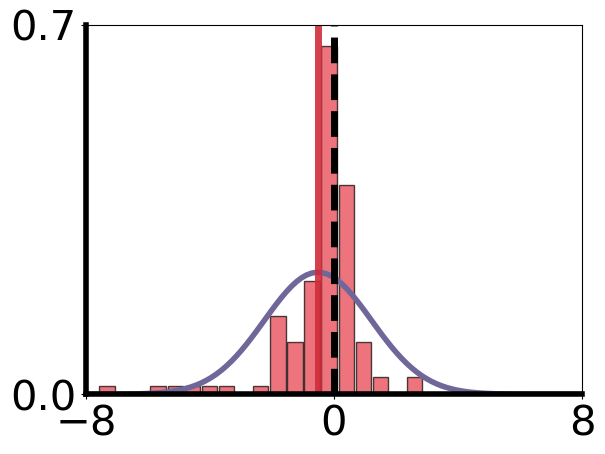

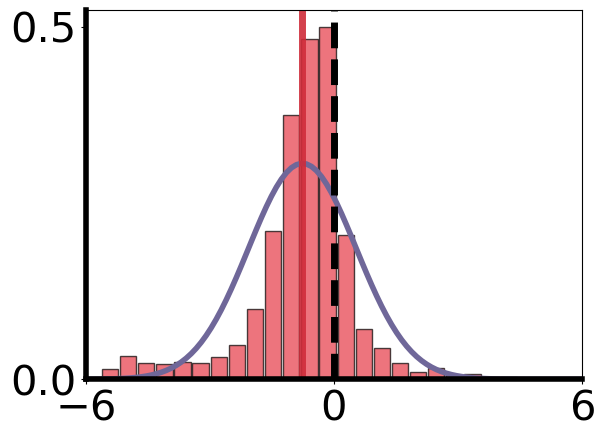

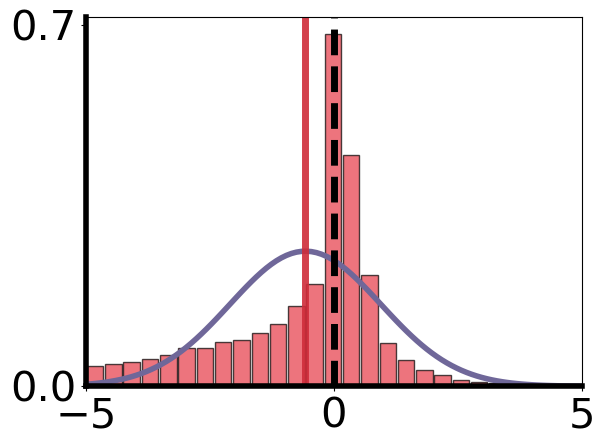

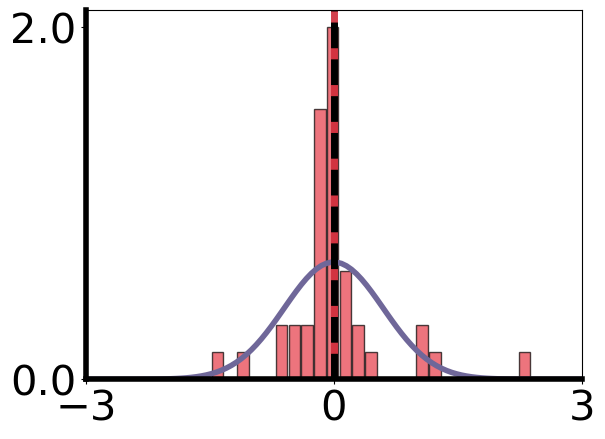

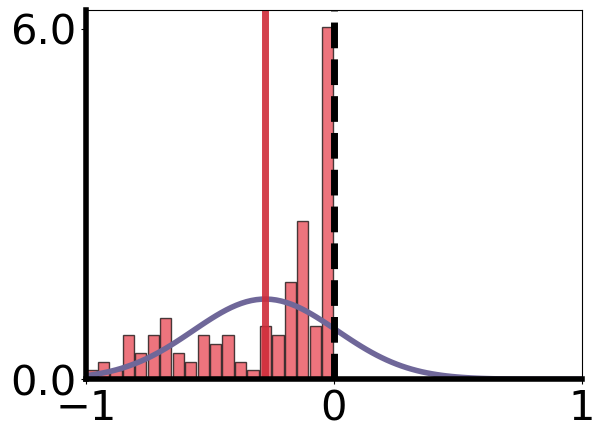

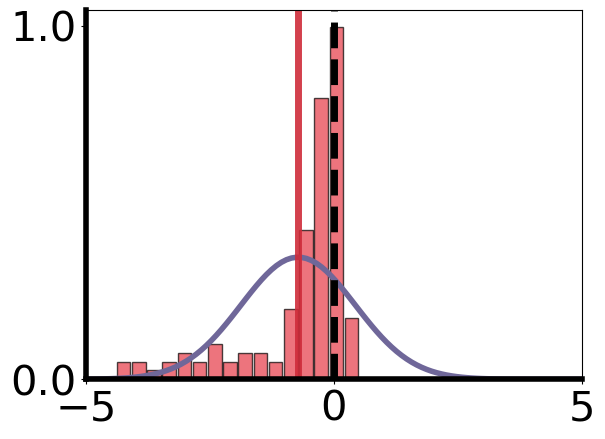

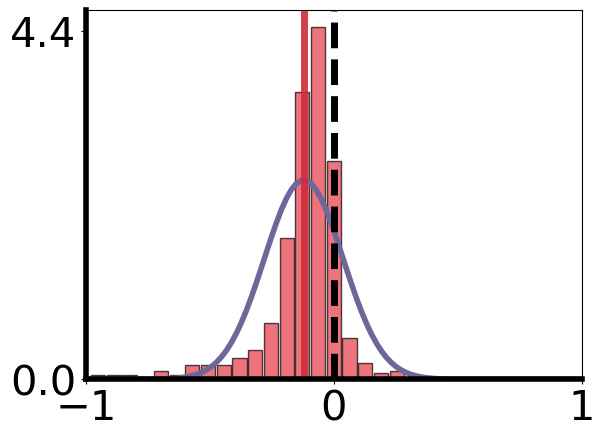

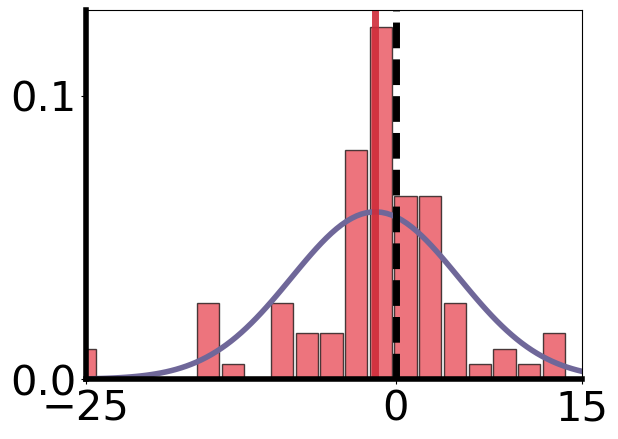

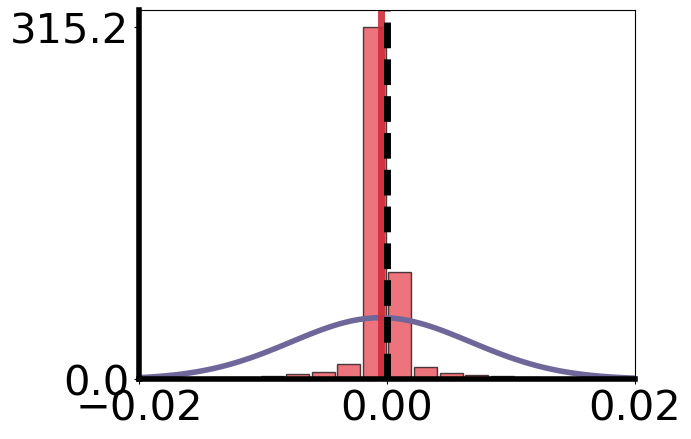

In [18]:
for i in range(len(combined_data)):
    fig,ax = plt.subplots()
    ax.bar((combined_hists[i][1][:-1] + combined_hists[i][1][1:]) / 2, combined_hists[i][0], width=np.diff(combined_hists[i][1])*0.9,edgecolor='black',linewidth=1,color="#e63946",alpha=0.7)
    if i!=4:
        ax.plot(combined_gaussians[i][0], combined_gaussians[i][1], color="#6f6799", linewidth=4)
    if i==4:
        ax.plot(combined_gaussians[i][0], combined_gaussians[i][1], color="#6f6799", linewidth=4)
    xticks = [np.min(combined_gaussians[i][0]),0,np.max(combined_gaussians[i][0])]
    yticks = [0.0,np.round(np.max(combined_hists[i][0]),1)]

    plt.axvline(np.mean(combined_data[i]),color="#cf2c3a",linewidth=5,alpha=0.9)

    tick_formatter = lambda x: "{:.1f}".format(x)
    plt.xticks(xticks,fontsize=30)
    plt.yticks(yticks,[tick_formatter(tick) for tick in yticks],fontsize=30)
    ax.set_xlim(np.min(combined_gaussians[i][0]), np.max(combined_gaussians[i][0]))
    for axis in ['bottom','left']:
        ax.spines[axis].set_linewidth(4)
    plt.axvline(0,color='black',linewidth=5,linestyle='--')

    # plt.savefig(f"../figures/data_interactions/distribution_{i+1}.svg",format='svg',bbox_inches='tight')

    plt.show()

## Interactions in simulations

In [19]:
import sys
sys.path.append("../scripts/")
import cr_model
import utils

In [ ]:
# ### Simulation data processing -- run only once

# dataFolder = "../data/simulation_data/random_communities/"
# dataTimeStamp = "1764669681"

# numfiles = 10


# total_fail = 0
# total_runs = 0
# gaussian_id = []
# interaction_measures = []
# used_indices = []
# three_new_measures = []

# condition_position = 0
# for runID in range(numfiles):
#     parameterMetadata = utils.load_compressed_pickle(dataFolder + "/scaling_parallel_metadata_"+str(runID)+"_"+dataTimeStamp)
#     parameterData = utils.load_compressed_pickle(dataFolder + "/scaling_parallel_"+str(runID)+"_"+dataTimeStamp)
#     NsList,NrList,species_params,numRuns = parameterMetadata["NsList"],parameterMetadata["NrList"],parameterMetadata["species_params"],parameterMetadata["numRuns"]
#     for i in range(len(NsList)):
#         if(NsList[i]<NrList[i] and species_params[i][1]/species_params[i][0] <10):
#             cur_measures = np.zeros((numRuns,7))
#             for j in range(numRuns):
#                 cur_int = parameterData[i][6][j]
#                 non_diag_int = cur_int[~np.eye(cur_int.shape[0],dtype=bool)]
#                 shapiro_p = stats.normaltest(non_diag_int)[1]
#                 if(shapiro_p > 0.001):
#                     total_fail += 1
#                     gaussian_id.append([condition_position,j])
#                 total_runs += 1
                
#                 cur_measures[j,:] = measure_stats(non_diag_int)
#                 cur_weakness = np.sum(np.abs(non_diag_int) < np.std(non_diag_int)) / non_diag_int.size * 100
#                 cur_outliers = np.sum(np.abs(non_diag_int - np.mean(non_diag_int)) > 3*np.std(non_diag_int)) / non_diag_int.size * 100
#                 three_new_measures.append([cur_weakness, cur_outliers, np.mean(-non_diag_int),np.median(-non_diag_int), np.std(-non_diag_int)])

#             interaction_measures.append(cur_measures)
#             used_indices.append([runID,i])
#             condition_position += 1  
# interaction_measures = np.array(interaction_measures)
# used_indices = np.array(used_indices)
# three_new_measures = np.array(three_new_measures)
# gaussian_id = np.array(gaussian_id)  

# print(total_fail,interaction_measures.shape,total_fail/interaction_measures.shape[0]/interaction_measures.shape[1])

# cond_idx = gaussian_id[:, 0]
# run_idx  = gaussian_id[:, 1]

# gaussian_measures = interaction_measures[cond_idx, run_idx, :]

# print(total_fail/total_runs,total_runs)

# # np.save("../data/figures/fig1/interaction_measures.npy", interaction_measures)
# # np.save("../data/figures/fig1/gaussian_measures.npy", gaussian_measures)

18 (100, 10, 7) 0.018
0.018 1000


In [31]:
interaction_measures = np.load("../data/figures/fig1/interaction_measures.npy")
gaussian_measures = np.load("../data/figures/fig1/gaussian_measures.npy")

In [32]:
print("CV stats:")
print("Model", np.mean(interaction_measures[:,:,4].flatten()), np.std(interaction_measures[:,:,4].flatten()),stats.iqr(interaction_measures[:,:,4].flatten()),np.median(interaction_measures[:,:,4].flatten()))
print("Data", np.mean(data_measures[:,4]), np.std(data_measures[:,4]), stats.iqr(data_measures[:,4]), np.median(data_measures[:,4]))

print("Skew stats:")
print("Model", np.mean(interaction_measures[:,:,2].flatten()), np.std(interaction_measures[:,:,2].flatten()), stats.iqr(interaction_measures[:,:,2].flatten()), np.median(interaction_measures[:,:,2].flatten()))
print("Data", np.mean(data_measures[:,2]), np.std(data_measures[:,2]), stats.iqr(data_measures[:,2]), np.median(data_measures[:,2]))

print("Kurtosis stats:")
print("Model", np.mean(interaction_measures[:,:,3].flatten()), np.std(interaction_measures[:,:,3].flatten()), stats.iqr(interaction_measures[:,:,3].flatten()), np.median(interaction_measures[:,:,3].flatten()))
print("Data", np.mean(data_measures[:,3]), np.std(data_measures[:,3]), stats.iqr(data_measures[:,3]), np.median(data_measures[:,3]))

print("Proportion negative stats:")
print("Model", np.mean(interaction_measures[:,:,0].flatten()), np.std(interaction_measures[:,:,0].flatten()), stats.iqr(interaction_measures[:,:,0].flatten()), np.median(interaction_measures[:,:,0].flatten()))
print("Data", np.mean(data_measures[:,0]), np.std(data_measures[:,0]), stats.iqr(data_measures[:,0]), np.median(data_measures[:,0]))

print("Weakness fraction stats:")
print("Model", np.mean(interaction_measures[:,:,5].flatten())*100, np.std(interaction_measures[:,:,5].flatten())*100,np.median(interaction_measures[:,:,5].flatten())*100)
print("Data", np.mean(data_measures[:,5])*100, np.std(data_measures[:,5])*100, np.median(data_measures[:,5])*100)

print("Outlier fraction stats:")
print("Model", np.mean(interaction_measures[:,:,6].flatten())*100, np.std(interaction_measures[:,:,6].flatten())*100, np.median(interaction_measures[:,:,6].flatten())*100)
print("Data", np.mean(data_measures[:,6])*100, np.std(data_measures[:,6])*100, np.median(data_measures[:,6])*100)

CV stats:
Model 0.7720705687925938 0.4707897119559211 0.4619411587958211 0.7199949292787635
Data 23.36811424653014 55.501352501593246 2.426434487378687 2.642684000987939
Skew stats:
Model 2.4572167839850643 2.895856526153961 1.7984698359996807 2.0200783391643746
Data 1.6993897129851057 1.929881092629672 1.1504408434303315 0.9415819390840128
Kurtosis stats:
Model 28.27131285833039 113.92606709828056 13.690442238113963 7.711898759046938
Data 19.678071841178262 43.6820180699091 3.8490475351918665 3.3654126910217492
Proportion negative stats:
Model 0.9915784496437363 0.02005872840044397 0.005327579655864945 0.9998291182501708
Data 0.7268747224619619 0.1468573350926717 0.21392221010541623 0.6907445748025458
Weakness fraction stats:
Model 39.728680329932104 26.599733082932115 41.70759476312826
Data 78.19404209405619 7.517180382723576 77.41935483870968
Outlier fraction stats:
Model 1.3800902428413842 0.5245619113596435 1.4838060988916033
Data 1.7683162608674667 0.9972256363768213 2.1505376344

In [33]:
data_markers = ["o","s","^","D","v","p","h","o","s"]
data_colors = ["#335c67","#bdab45","#c97d0c","#9e2a2b","#540b0e","#219ebc","#31572c","#6d57db","#b63d97"]

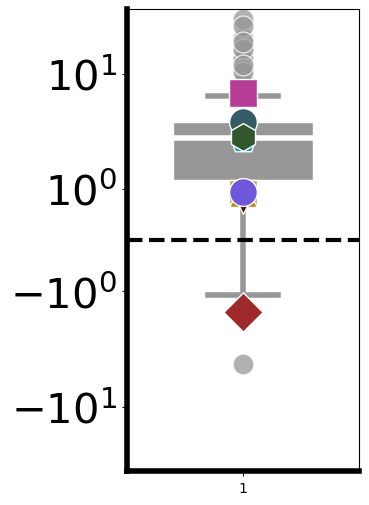

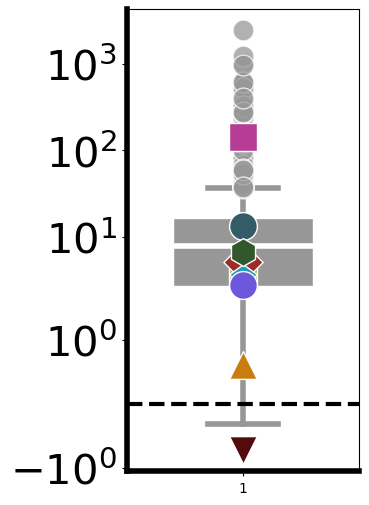

In [34]:
fig,ax = plt.subplots(figsize=(3,6))
bp = plt.boxplot(interaction_measures[:,:,2].flatten(),bootstrap=10000,flierprops={'marker': 'o', 'markersize': 15, 'markerfacecolor': '#979797','alpha':0.75,'markeredgecolor':'white'},patch_artist=True,
                 capprops={'linewidth':4,'color':"#979797"},whiskerprops={'linewidth':4,'color':"#979797"},medianprops={'linewidth':4,'color':'white'},boxprops={'edgecolor':'white','facecolor':'#979797'},widths=0.6)
for i in range(len(combined_data)):
    plt.scatter(1,data_measures[i,2],s=400,label=f"{i+1}",color=f"C{i+2}",marker=data_markers[i],zorder=10,alpha=1,edgecolors="white",lw=1,facecolors=data_colors[i])
plt.yscale("symlog")
# plt.legend(labelspacing=2)
plt.yticks([-10,-1,1,10],fontsize=30)
plt.ylim(-50,50)
plt.axhline(0,color='black',linewidth=3,linestyle='--')
for axis in ['left', 'bottom']:
    bp['boxes'][0].axes.spines[axis].set_linewidth(4)
# plt.savefig("../figures/data_interactions/interaction_skew_boxplot.svg",format='svg',bbox_inches='tight')
plt.show()

fig,ax = plt.subplots(figsize=(3,6))
plt.boxplot((interaction_measures[:,:,3].flatten()),bootstrap=10000,flierprops={'marker': 'o', 'markersize': 15, 'markerfacecolor': '#979797','alpha':0.75,'markeredgecolor':'white'},patch_artist=True,
                 capprops={'linewidth':4,'color':"#979797"},whiskerprops={'linewidth':4,'color':"#979797"},medianprops={'linewidth':4,'color':'white'},boxprops={'edgecolor':'white','facecolor':'#979797'},widths=0.6)
for i in range(len(combined_data)):
    plt.scatter(1,(data_measures[i,3]),s=400,label=f"{i+1}",color=f"C{i+2}",marker=data_markers[i],zorder=10,alpha=1,edgecolors="white",lw=1,facecolors=data_colors[i])
plt.yscale("symlog",linthresh=1.5)
# plt.legend(labelspacing=2)
plt.yticks([-1,1,10,100,1000],fontsize=30)
plt.axhline(0,color='black',linewidth=3,linestyle='--')
for axis in ['left', 'bottom']:
    plt.gca().spines[axis].set_linewidth(4)
# plt.savefig("../figures/data_interactions/interaction_excess_kurtosis_boxplot.svg",format='svg',bbox_inches='tight')
plt.show()

In [35]:
simulation_linregress = stats.linregress(np.log10(np.abs(interaction_measures[:,:,2].flatten())), np.log10(np.abs(interaction_measures[:,:,3].flatten())))
print(simulation_linregress)

LinregressResult(slope=1.676030351617249, intercept=0.42044837756926906, rvalue=0.9519706292863713, pvalue=0.0, stderr=0.017064090531617997, intercept_stderr=0.008372750088613308)


In [36]:
skew_range = np.linspace(np.min(np.abs(interaction_measures[:,:,2].flatten())), np.max(np.abs(interaction_measures[:,:,2].flatten())), 10)

In [37]:
def predictive_r2(x_data, y_data, slope, intercept):
    y_pred = slope * x_data + intercept
    ss_res = np.sum((y_data - y_pred) ** 2)
    ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
    return 1 - ss_res / ss_tot

In [38]:
predictive_r2(np.log10(np.abs(data_measures[:,2])), np.log10(np.abs(data_measures[:,3])), simulation_linregress.slope, simulation_linregress.intercept)

0.7817579590911976

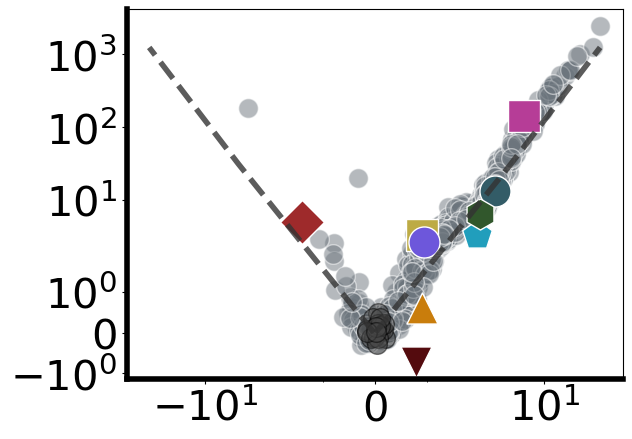

In [39]:
plt.scatter(interaction_measures[:,:,2].flatten(),interaction_measures[:,:,3].flatten(),label="Model",color="#6c757d",alpha=0.5,edgecolors="white",s=200)
for i in range(len(data_measures)):
    plt.scatter(data_measures[i,2],data_measures[i,3],s=500,marker=data_markers[i],label=f"{i+1}",color=data_colors[i],edgecolors="#ffffff",lw=1)
plt.plot(skew_range, 10**(simulation_linregress.intercept + simulation_linregress.slope * np.log10(skew_range)), color="#333333", linewidth=4,ls="--",alpha=0.8)
plt.plot(-skew_range, 10**(simulation_linregress.intercept + simulation_linregress.slope * np.log10(skew_range)), color="#333333", linewidth=4,ls="--",alpha=0.8)
# plt.scatter(0,0,s=1200,marker="o",color="#008000",alpha=0.5,label="Gaussian",edgecolors="none",zorder=10)
plt.scatter(gaussian_measures[:,2],gaussian_measures[:,3],s=200,marker="o",label=f"Gaussian",color="#474747",edgecolors="#000000",lw=1,alpha=0.5)

plt.yscale("symlog",linthresh=2)
plt.xscale("symlog",linthresh=2)
# plt.legend(labelspacing=2,loc="upper left")
for axis in ['left', 'bottom']:
    plt.gca().spines[axis].set_linewidth(4)
plt.xticks([-10,0,10],fontsize=30)
plt.yticks([-1,0,1,10,100,1000],fontsize=30)
# plt.savefig("../figures/data_interactions/interaction_skew_kurtosis_scatter.svg",format='svg',bbox_inches='tight')
plt.show()

# Data analysis

### clark et al posterior sampling

In [12]:
import os

In [13]:
clark_data_folder = "../data/clark_et_al/RLC9 Model Training/outputs/RLC9_posterior_fixedprior/"
sample_list = os.listdir(clark_data_folder)
avg_interaction = np.zeros((25,25))
for sampleID in range(len(sample_list)):
    cur_inter = pd.read_csv(clark_data_folder + sample_list[sampleID],header=None).values.reshape(26,25,order="F")[1:]
    avg_interaction += cur_inter
avg_interaction /= len(sample_list)

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
np.save("../data/clark_et_al/interaction.npy", avg_interaction)

### flor's data

In [124]:
flor_data = pd.read_csv("../data/interaction_data/flor_et_al/flor_interactions.csv")

In [125]:
filtered_data = flor_data[(flor_data['Treatment'] == 'Ancestral')]
print(stats.normaltest(filtered_data["Mean_interaction"].to_numpy()),stats.skew(filtered_data["Mean_interaction"].to_numpy()),stats.kurtosis(filtered_data["Mean_interaction"].to_numpy(),fisher=True))
# np.save("../data/interaction_data/flor_et_al/filtered_interactions.npy", filtered_data["Mean_interaction"].to_numpy())

NormaltestResult(statistic=22.651936440451472, pvalue=1.2055757392492404e-05) -0.9415819390840128 2.7284996832810595


In [61]:
hist,edges = np.histogram(filtered_data["Mean_interaction"].to_numpy(),bins=15,density=True)
mean,std = np.mean(filtered_data["Mean_interaction"].to_numpy()), np.std(filtered_data["Mean_interaction"].to_numpy())
xrange = np.linspace(np.min(edges), np.max(edges), 100)
gaussian = 1/(std*np.sqrt(2*np.pi))*np.exp(-0.5*((xrange-mean)/std)**2)

In [63]:
np.mean(filtered_data["Mean_interaction"].to_numpy()), np.std(filtered_data["Mean_interaction"].to_numpy()), np.median(filtered_data["Mean_interaction"].to_numpy())

(-1.6782424996684777, 6.754844049713786, -0.982528169019456)

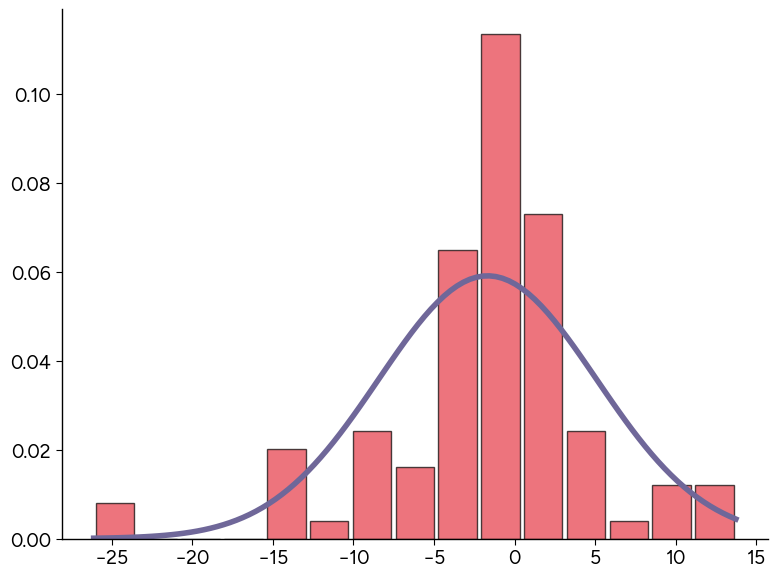

In [62]:
plt.bar((edges[:-1] + edges[1:]) / 2, hist, width=np.diff(edges)*0.9,edgecolor='black',linewidth=1,color="#e63946",alpha=0.7)
plt.plot(xrange, gaussian, color="#6f6799", linewidth=4)

### marine data

In [132]:
datafile = pd.read_csv("../data/interaction_data/marine/MDR_smap_interactions_Scripps_Pier_ASVs_tp_2_28092024.csv")

In [133]:
mean_interactions = datafile.groupby(["target_1","target_2"]).agg({"MDR_smap_coefficient":"mean"}).reset_index()

In [135]:
mean_interactions["target_1"].unique().size

162

In [5]:
mean_interactions[mean_interactions["target_1"]==mean_interactions["target_2"]]

,target_1,target_2,MDR_smap_coefficient
0,Actinobacteria_410_1,Actinobacteria_410_1,0.578353
163,Actinobacteria_410_2,Actinobacteria_410_2,0.872856
326,Archaea_164_1,Archaea_164_1,0.536170
489,Archaea_164_2,Archaea_164_2,0.813210
652,Archaea_179_1,Archaea_179_1,0.395697
...,...,...,...
25591,Verrucomicrobia_18_1,Verrucomicrobia_18_1,0.386919
25754,Verrucomicrobia_18_3,Verrucomicrobia_18_3,0.494285
25917,Verrucomicrobia_18_4,Verrucomicrobia_18_4,0.935709
26080,Verrucomicrobia_22_1,Verrucomicrobia_22_1,0.698372


In [70]:
reduced_interactions = -mean_interactions["MDR_smap_coefficient"][mean_interactions["target_1"]!=mean_interactions["target_2"]].to_numpy()
# reduced_interactions = reduced_interactions[reduced_interactions!=0]
hist,edges = np.histogram(reduced_interactions,bins=100,density=True)
mean = np.mean(reduced_interactions)
std = np.std(reduced_interactions)
xrange = np.linspace(-0.2,0.2, 10000)
gaussian = 1/(std*np.sqrt(2*np.pi))*np.exp(-0.5*((xrange-mean)/std)**2)
print(np.mean(reduced_interactions), np.std(reduced_interactions), np.median(reduced_interactions))

-0.0004912879853195723 0.007232101175099223 0.0


In [ ]:
# np.save("../data/interaction_data/marine/filtered_interactions.npy", reduced_interactions)

(-0.05, 0.05)

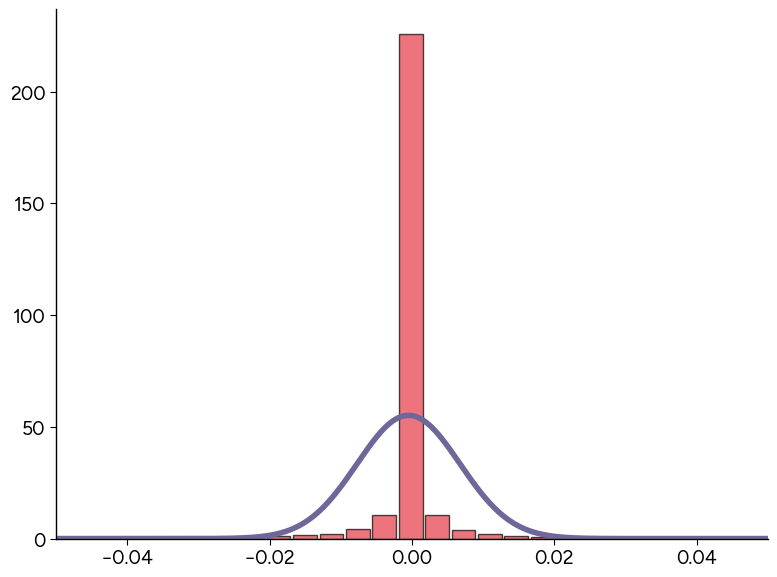

In [73]:
plt.bar((edges[:-1] + edges[1:]) / 2, hist, width=np.diff(edges)*0.9,edgecolor='black',linewidth=1,color="#e63946",alpha=0.7)
plt.plot(xrange, gaussian, color="#6f6799", linewidth=4)
plt.xlim(-0.05,0.05)
# plt.xscale("symlog",linthresh=0.01)